# Elastic Net: regularización L1 + L2

## Objetivos de aprendizaje

Al finalizar este laboratorio podrás:

- explicar cómo `alpha` controla la regularización total y `l1_ratio` combina L1 y L2;
- comparar ElasticNet con LinearRegression y un baseline trivial;
- seleccionar conjuntamente ambos hiperparámetros con ElasticNetCV, GridSearchCV y BayesOpt temporal;
- interpretar contracción y coeficientes cero considerando la correlación entre predictores.

## Problema y datos

Se estima `Consumption` en observaciones horarias del CSV eléctrico a partir de producción por fuente y variables temporales. Como se usan predictores contemporáneos de producción, el modelo representa consumo condicionado a producción observada; no es un pronóstico futuro a menos que esas variables estén disponibles en el horizonte.

Las observaciones se ordenan y se dividen cronológicamente en train, validation y test. El escalador se ajusta solo con train y cada método de tuning usa `TimeSeriesSplit`; validation ayuda a comparar métodos y test queda reservado para la evaluación final.

In [ ]:
# Librerias para manipulacion de datos y visualizacion
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Baselines, modelos ElasticNet y metricas
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Preprocesamiento: el escalador se ajusta solo con train.
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Ajustes de visualizacion para tablas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

In [ ]:
# Construimos una ruta reproducible al archivo fuente compartido
from machine_learning.data import get_data_path

csv_path = get_data_path("electricity_consumption_and_production.csv", category="external")
if not csv_path.exists():
    raise FileNotFoundError(f'No se encontro el archivo: {csv_path.resolve()}')

# Cargamos datos originales (consumo + produccion por fuente)
raw = pd.read_csv(csv_path)

# Convertimos DateTime a formato fecha y lo usamos como indice temporal
raw['DateTime'] = pd.to_datetime(raw['DateTime'])
raw = raw.sort_values('DateTime').set_index('DateTime')

# Resumen rapido para entender tamano, columnas y posibles faltantes
print('Shape del dataset original:', raw.shape)
print('Columnas disponibles:', list(raw.columns))
print('Valores nulos por columna:')
print(raw.isna().sum())

# Visualizamos primeras filas del dataset completo
display(raw.head())

Shape del dataset original: (62810, 9)
Columnas disponibles: ['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
Valores nulos por columna:
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [ ]:
# Funcion para generar variables temporales a partir del indice de fechas
def create_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['hour'] = out.index.hour
    out['day_of_week'] = out.index.day_of_week
    out['month'] = out.index.month
    out['quarter'] = out.index.quarter
    out['year'] = out.index.year
    out['day_of_year'] = out.index.dayofyear
    return out

feat_df = create_time_features(raw)
energy_candidate_features = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass',
]
categorical_time_features = ['hour', 'day_of_week', 'month', 'quarter', 'year']
numeric_features = energy_candidate_features + ['day_of_year']
TARGET = 'Consumption'

# Conservamos las categorias; OneHotEncoder se ajusta despues del split.
model_df = feat_df[['Consumption'] + numeric_features + categorical_time_features].copy()
print('Ingenieria temporal completada; categorias pendientes de codificacion train-only.')
print('Observaciones y features preliminares:', model_df.shape)
print('Variables categoricas de calendario:', categorical_time_features)

Correlacion (ordenada por magnitud absoluta) con Consumption:


,corr_vs_consumption
Production,0.690823
Oil and Gas,0.499442
Coal,0.472298
Biomass,0.400475
Hydroelectric,0.358047
Nuclear,0.161838
Wind,0.102026
Solar,-0.048037


Candidatas fuertes (|corr| >= 0.25): ['Production', 'Oil and Gas', 'Coal', 'Biomass', 'Hydroelectric']
Candidatas moderadas (0.10 <= |corr| < 0.25): ['Nuclear', 'Wind']


In [ ]:
# Variables candidatas de energia para el analisis exploratorio.
# La correlacion con Consumption se calcula despues del split y solo en train.
candidate_cols = [
    'Production', 'Nuclear', 'Wind', 'Hydroelectric',
    'Oil and Gas', 'Coal', 'Solar', 'Biomass',
]
print('Variables energeticas candidatas:', candidate_cols)

Ingenieria completada.
Total de features para el modelo: 59
Primeras 10 features: ['Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'day_of_year', 'hour_1']


In [ ]:
# Particion temporal cronologica: train 70%, validation 15%, test 15%.
model_df = model_df.sort_index()
n_rows = len(model_df)
train_end = int(n_rows * 0.70)
validation_end = int(n_rows * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:validation_end].copy()
test_df = model_df.iloc[validation_end:].copy()

# Correlaciones descriptivas calculadas solo en train.
corr_with_target = train_df[['Consumption'] + candidate_cols].corr(numeric_only=True)['Consumption']
corr_with_target = corr_with_target.drop('Consumption').sort_values(key=np.abs, ascending=False)
display(corr_with_target.to_frame('corr_vs_consumption_train'))
strong_candidates = corr_with_target[np.abs(corr_with_target) >= 0.25].index.tolist()
moderate_candidates = corr_with_target[
    (np.abs(corr_with_target) >= 0.10) & (np.abs(corr_with_target) < 0.25)
].index.tolist()

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
encoder.fit(train_df[categorical_time_features])
encoded_columns = encoder.get_feature_names_out(categorical_time_features)

def encode_calendar_features(partition):
    encoded = encoder.transform(partition[categorical_time_features])
    encoded_frame = pd.DataFrame(encoded, columns=encoded_columns, index=partition.index)
    return pd.concat([partition.drop(columns=categorical_time_features), encoded_frame], axis=1)

train_df = encode_calendar_features(train_df)
val_df = encode_calendar_features(val_df)
test_df = encode_calendar_features(test_df)
FEATURES = [column for column in train_df.columns if column != TARGET]

# Escalamos variables energeticas con estadisticas aprendidas solo en train.
cast_map = {column: 'float64' for column in energy_candidate_features}
train_df = train_df.astype(cast_map)
val_df = val_df.astype(cast_map)
test_df = test_df.astype(cast_map)
scaler = StandardScaler()
train_df.loc[:, energy_candidate_features] = scaler.fit_transform(train_df[energy_candidate_features])
val_df.loc[:, energy_candidate_features] = scaler.transform(val_df[energy_candidate_features])
test_df.loc[:, energy_candidate_features] = scaler.transform(test_df[energy_candidate_features])

model_df = pd.concat([train_df, val_df, test_df]).sort_index()
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val, y_val = val_df[FEATURES], val_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print('Observaciones train:', X_train.shape[0])
print('Observaciones validation:', X_val.shape[0])
print('Observaciones test:', X_test.shape[0])
print('Train:', train_df.index.min(), '->', train_df.index.max())
print('Validation:', val_df.index.min(), '->', val_df.index.max())
print('Test:', test_df.index.min(), '->', test_df.index.max())
print('Media train estandarizada (aprox. 0):', train_df[energy_candidate_features].mean().round(3).to_dict())
print('Desviacion train estandarizada (aprox. 1):', train_df[energy_candidate_features].std().round(3).to_dict())

Train size: (43967, 59)
Validation size: (9421, 59)
Test size: (9422, 59)
Random state usado: 42
Media train estandarizada (aprox 0):
{'Production': 0.0, 'Nuclear': -0.0, 'Wind': -0.0, 'Hydroelectric': -0.0, 'Oil and Gas': -0.0, 'Coal': -0.0, 'Solar': 0.0, 'Biomass': -0.0}
Std train estandarizada (aprox 1):
{'Production': 1.0, 'Nuclear': 1.0, 'Wind': 1.0, 'Hydroelectric': 1.0, 'Oil and Gas': 1.0, 'Coal': 1.0, 'Solar': 1.0, 'Biomass': 1.0}


In [ ]:
# Ajustamos DummyRegressor, regresion lineal y ElasticNet.
linear_model = LinearRegression().fit(X_train, y_train)
elasticnet_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=20000,
    random_state=42,
).fit(X_train, y_train)
dummy_model = DummyRegressor(strategy='mean').fit(X_train, y_train)

model_predictions = {
    'DummyRegressor (media)': (dummy_model.predict(X_val), dummy_model.predict(X_test)),
    'LinearRegression': (linear_model.predict(X_val), linear_model.predict(X_test)),
    'ElasticNet (alpha=1.0, l1_ratio=0.5)': (
        elasticnet_model.predict(X_val), elasticnet_model.predict(X_test),
    ),
}
pred_val, pred_elasticnet = model_predictions['ElasticNet (alpha=1.0, l1_ratio=0.5)']

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = y_true != 0
    if not np.any(nonzero):
        return float('nan')
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

results = pd.DataFrame([
    {
        'split': split_name,
        'modelo': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MAPE_%': mape(y_true, y_pred),
    }
    for split_name, y_true, prediction_index in [
        ('validation', y_val, 0),
        ('test', y_test, 1),
    ]
    for model_name, model_prediction in model_predictions.items()
    for y_pred in [model_prediction[prediction_index]]
]).set_index(['split', 'modelo'])

# Magnitud de coeficientes: evidencia descriptiva, no efecto causal.
coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coef': elasticnet_model.coef_,
    'abs_coef': np.abs(elasticnet_model.coef_),
}).sort_values('abs_coef', ascending=False)
zero_coefficients = int(np.count_nonzero(elasticnet_model.coef_ == 0))

print('Comparacion de baseline, regresion lineal y ElasticNet:')
display(results.round(4))
print(f'Coeficientes exactamente cero: {zero_coefficients} de {len(FEATURES)}')
print('Top 12 coeficientes ElasticNet por magnitud absoluta:')
display(coef_df[['feature', 'coef']].head(12))

Top 12 features por magnitud de coeficiente:


,feature,coef
0,Production,279.016885
4,Oil and Gas,208.439789
5,Coal,188.295064
3,Hydroelectric,184.093593
7,Biomass,120.163301
37,day_of_week_6,-99.601159
55,year_2023,-65.821043
49,quarter_2,-56.345628
11,hour_3,-52.432125
10,hour_2,-50.563651


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,ElasticNet,524.5688,645.1625,0.6310,8.3516
test,ElasticNet,514.5254,631.5817,0.6499,8.1955


Resumen de error en test:
       error_elasticnet  abs_error
count          9422.000   9422.000
mean             -8.468    514.525
std             631.558    366.297
min           -2202.275      0.006
25%            -458.295    224.556
50%             -19.227    450.160
75%             444.026    738.720
max            2305.682   2305.682


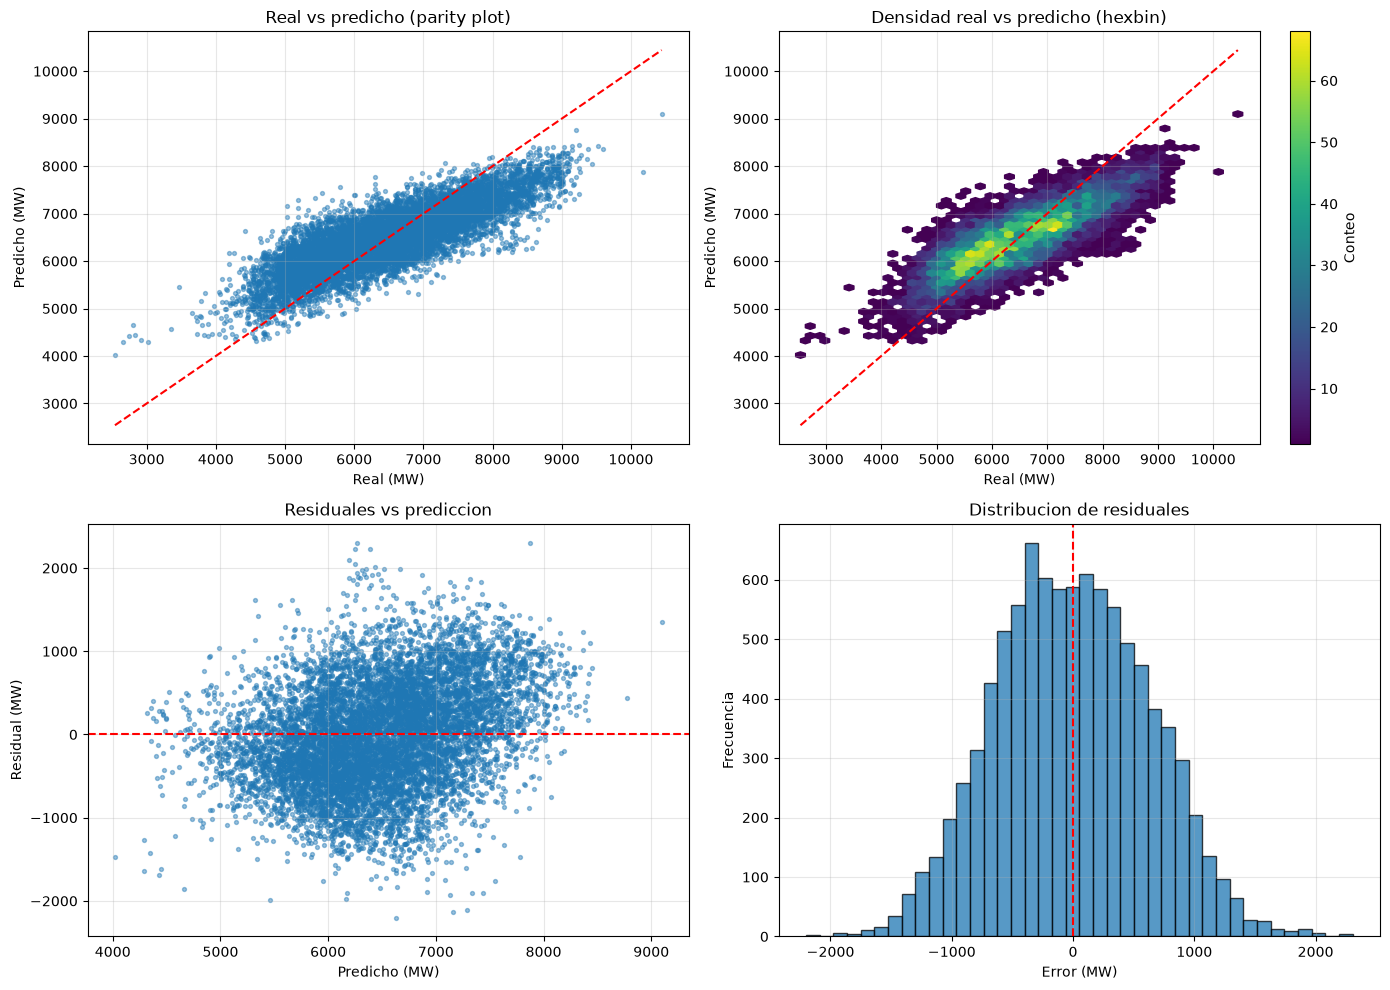

In [7]:
# Analisis de predicciones para split aleatorio (sin orden temporal)
pred_df = pd.DataFrame(index=y_test.index)
pred_df['Consumption'] = y_test
pred_df['pred_elasticnet'] = pred_elasticnet
pred_df['error_elasticnet'] = pred_df['Consumption'] - pred_df['pred_elasticnet']
pred_df['abs_error'] = pred_df['error_elasticnet'].abs()

print('Resumen de error en test:')
print(pred_df[['error_elasticnet', 'abs_error']].describe().round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Parity plot: real vs predicho
axes[0, 0].scatter(pred_df['Consumption'], pred_df['pred_elasticnet'], s=8, alpha=0.45)
min_v = min(pred_df['Consumption'].min(), pred_df['pred_elasticnet'].min())
max_v = max(pred_df['Consumption'].max(), pred_df['pred_elasticnet'].max())
axes[0, 0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 0].set_title('Real vs predicho (parity plot)')
axes[0, 0].set_xlabel('Real (MW)')
axes[0, 0].set_ylabel('Predicho (MW)')
axes[0, 0].grid(alpha=0.3)

# 2) Hexbin para densidad de puntos
hb = axes[0, 1].hexbin(
    pred_df['Consumption'],
    pred_df['pred_elasticnet'],
    gridsize=45,
    cmap='viridis',
    mincnt=1
)
axes[0, 1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0, 1].set_title('Densidad real vs predicho (hexbin)')
axes[0, 1].set_xlabel('Real (MW)')
axes[0, 1].set_ylabel('Predicho (MW)')
axes[0, 1].grid(alpha=0.3)
fig.colorbar(hb, ax=axes[0, 1], label='Conteo')

# 3) Residuales vs prediccion
axes[1, 0].scatter(pred_df['pred_elasticnet'], pred_df['error_elasticnet'], s=8, alpha=0.45)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Residuales vs prediccion')
axes[1, 0].set_xlabel('Predicho (MW)')
axes[1, 0].set_ylabel('Residual (MW)')
axes[1, 0].grid(alpha=0.3)

# 4) Histograma de residuales
axes[1, 1].hist(pred_df['error_elasticnet'], bins=40, edgecolor='black', alpha=0.75)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('Distribucion de residuales')
axes[1, 1].set_xlabel('Error (MW)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Interpretación de coeficientes ElasticNet

ElasticNet combina la contracción L2 de Ridge con la posibilidad de producir coeficientes cero de Lasso. `alpha` controla la intensidad total y `l1_ratio` la proporción de L1: valores cercanos a 0 se aproximan a Ridge y valores cercanos a 1 a Lasso.

La celda de ajuste informa cuántos coeficientes resultaron exactamente cero en esta ejecución. Si predictores están correlacionados, la selección puede distribuirse entre ellos y cambiar al variar el periodo o la muestra. Los coeficientes describen asociaciones condicionales, no efectos causales; interpreta magnitudes considerando las escalas.

In [ ]:
# Busqueda conjunta de alpha y l1_ratio con folds temporales.
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit

alpha_grid = np.logspace(-2, 1, 12)
l1_ratio_grid = [0.1, 0.3, 0.5, 0.7, 0.9]
cv_temporal = TimeSeriesSplit(n_splits=5)
elasticnet_cv = ElasticNetCV(
    alphas=alpha_grid,
    l1_ratio=l1_ratio_grid,
    cv=cv_temporal,
    max_iter=20000,
    random_state=42,
)
elasticnet_cv.fit(X_train, y_train)

best_alpha = elasticnet_cv.alpha_
best_l1_ratio = elasticnet_cv.l1_ratio_
elasticnet_tuned = ElasticNet(
    alpha=best_alpha,
    l1_ratio=best_l1_ratio,
    max_iter=20000,
    random_state=42,
)
elasticnet_tuned.fit(X_train, y_train)
pred_val_tuned = elasticnet_tuned.predict(X_val)
pred_test_tuned = elasticnet_tuned.predict(X_test)

def mape_local(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = y_true != 0
    if not np.any(nonzero):
        return float('nan')
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

elasticnet_cv_results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': f'ElasticNetCV (alpha={best_alpha:.6g}, l1_ratio={best_l1_ratio:.2f})',
        'MAE': mean_absolute_error(y_val, pred_val_tuned),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val_tuned)),
        'R2': r2_score(y_val, pred_val_tuned),
        'MAPE_%': mape_local(y_val, pred_val_tuned),
    },
    {
        'split': 'test',
        'modelo': f'ElasticNetCV (alpha={best_alpha:.6g}, l1_ratio={best_l1_ratio:.2f})',
        'MAE': mean_absolute_error(y_test, pred_test_tuned),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_test_tuned)),
        'R2': r2_score(y_test, pred_test_tuned),
        'MAPE_%': mape_local(y_test, pred_test_tuned),
    },
]).set_index(['split', 'modelo'])

comparison_df = pd.DataFrame([
    {
        'modelo': 'ElasticNet base',
        'alpha': elasticnet_model.alpha,
        'l1_ratio': elasticnet_model.l1_ratio,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, elasticnet_model.predict(X_val))),
    },
    {
        'modelo': 'ElasticNetCV seleccionado',
        'alpha': best_alpha,
        'l1_ratio': best_l1_ratio,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, pred_val_tuned)),
    },
])

print('Alpha seleccionado por ElasticNetCV:', best_alpha)
print('l1_ratio seleccionado por ElasticNetCV:', best_l1_ratio)
print('\nMetricas de validation/test:')
display(elasticnet_cv_results.round(4))
print('\nComparacion rapida de parametros en validation:')
display(comparison_df.round(6))

c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.169270e+06, tolerance: 3.295e+06
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.467110e+06, tolerance: 3.318e+06
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You migh

Alpha seleccionado por ElasticNetCV: 0.01
l1_ratio seleccionado por ElasticNetCV: 0.9

Resumen de metricas del modelo ajustado:


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,"ElasticNetCV (alpha=0.01, l1_ratio=0.90)",334.2943,433.5085,0.8334,5.3232
test,"ElasticNetCV (alpha=0.01, l1_ratio=0.90)",326.6377,425.6616,0.8410,5.2123



Comparacion de hiperparametros y RMSE en validation:


,modelo,alpha,l1_ratio,RMSE_val
0,ElasticNet base,1.00,0.5,645.162512
1,ElasticNetCV seleccionado,0.01,0.9,433.508546


In [ ]:
# GridSearchCV conjunto para alpha y l1_ratio con folds temporales.
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

alpha_grid_gs = np.logspace(-2, 1, 12)
l1_ratio_grid_gs = [0.1, 0.3, 0.5, 0.7, 0.9]
cv_temporal = TimeSeriesSplit(n_splits=5)
elasticnet_gs = GridSearchCV(
    estimator=ElasticNet(max_iter=20000, random_state=42),
    param_grid={'alpha': alpha_grid_gs, 'l1_ratio': l1_ratio_grid_gs},
    scoring='neg_root_mean_squared_error',
    cv=cv_temporal,
    n_jobs=-1,
    refit=True,
)
elasticnet_gs.fit(X_train, y_train)

best_alpha_gs = elasticnet_gs.best_params_['alpha']
best_l1_ratio_gs = elasticnet_gs.best_params_['l1_ratio']
elasticnet_gs_best = elasticnet_gs.best_estimator_
pred_val_gs = elasticnet_gs_best.predict(X_val)
pred_test_gs = elasticnet_gs_best.predict(X_test)

def mape_local(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = y_true != 0
    if not np.any(nonzero):
        return float('nan')
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

gridsearch_results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': f'ElasticNet GridSearchCV (alpha={best_alpha_gs:.6g}, l1_ratio={best_l1_ratio_gs:.2f})',
        'MAE': mean_absolute_error(y_val, pred_val_gs),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val_gs)),
        'R2': r2_score(y_val, pred_val_gs),
        'MAPE_%': mape_local(y_val, pred_val_gs),
    },
    {
        'split': 'test',
        'modelo': f'ElasticNet GridSearchCV (alpha={best_alpha_gs:.6g}, l1_ratio={best_l1_ratio_gs:.2f})',
        'MAE': mean_absolute_error(y_test, pred_test_gs),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_test_gs)),
        'R2': r2_score(y_test, pred_test_gs),
        'MAPE_%': mape_local(y_test, pred_test_gs),
    },
]).set_index(['split', 'modelo'])

comparison_alpha_methods = pd.DataFrame([
    {
        'metodo': 'ElasticNet base',
        'alpha': elasticnet_model.alpha,
        'l1_ratio': elasticnet_model.l1_ratio,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, elasticnet_model.predict(X_val))),
    },
    {
        'metodo': 'ElasticNetCV',
        'alpha': elasticnet_cv.alpha_,
        'l1_ratio': elasticnet_cv.l1_ratio_,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, elasticnet_tuned.predict(X_val))),
    },
    {
        'metodo': 'GridSearchCV',
        'alpha': best_alpha_gs,
        'l1_ratio': best_l1_ratio_gs,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, pred_val_gs)),
    },
]).sort_values('RMSE_val').reset_index(drop=True)

print('Parametros seleccionados por GridSearchCV:', elasticnet_gs.best_params_)
print('\nMetricas de validation/test:')
display(gridsearch_results.round(4))
print('\nComparacion de metodos en validation:')
display(comparison_alpha_methods.round(6))

Alpha seleccionado por GridSearchCV: 0.01
l1_ratio seleccionado por GridSearchCV: 0.9

Metricas del modelo ajustado por GridSearchCV:


c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.048676e+06, tolerance: 4.954e+06
  model = cd_fast.enet_coordinate_descent(


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,"ElasticNet GridSearchCV (alpha=0.01, l1_ratio=0.90)",334.2943,433.5085,0.8334,5.3232
test,"ElasticNet GridSearchCV (alpha=0.01, l1_ratio=0.90)",326.6378,425.6616,0.8410,5.2123



Comparacion de metodos para estimar ambos hiperparametros:


,metodo,alpha,l1_ratio,RMSE_val
0,GridSearchCV,0.01,0.9,433.508516
1,ElasticNetCV,0.01,0.9,433.508546
2,ElasticNet base,1.00,0.5,645.162512


In [ ]:
# Optimizacion bayesiana conjunta de alpha y l1_ratio con validacion temporal.
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from scipy.stats import norm

rng = np.random.default_rng(42)
log_alpha_bounds = (-2.0, 1.0)
l1_ratio_bounds = (0.01, 0.99)
n_initial = 6
n_iter = 8
cv_bayes = TimeSeriesSplit(n_splits=5)

def objective_rmse(params):
    log10_alpha, l1_ratio_value = params
    model = ElasticNet(
        alpha=float(10 ** log10_alpha),
        l1_ratio=float(l1_ratio_value),
        max_iter=20000,
        random_state=42,
    )
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='neg_root_mean_squared_error',
        cv=cv_bayes,
        n_jobs=-1,
    )
    return float(-scores.mean())

# Muestras iniciales reproducibles en el espacio de ambos hiperparametros.
X_obs = np.column_stack([
    rng.uniform(*log_alpha_bounds, size=n_initial),
    rng.uniform(*l1_ratio_bounds, size=n_initial),
])
y_obs = np.array([objective_rmse(params) for params in X_obs], dtype=float)

# Expected Improvement propone nuevas combinaciones.
for _ in range(n_iter):
    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.0, 0.3], nu=2.5) + WhiteKernel(noise_level=1e-6)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, random_state=42)
    gp.fit(X_obs, y_obs)

    log_alpha_grid = np.linspace(*log_alpha_bounds, 40)
    l1_ratio_grid = np.linspace(*l1_ratio_bounds, 25)
    mesh = np.array(np.meshgrid(log_alpha_grid, l1_ratio_grid)).reshape(2, -1).T
    mu, sigma = gp.predict(mesh, return_std=True)
    sigma = np.maximum(sigma, 1e-12)
    best_y = np.min(y_obs)
    z = (best_y - mu) / sigma
    expected_improvement = (best_y - mu) * norm.cdf(z) + sigma * norm.pdf(z)
    next_x = mesh[np.argmax(expected_improvement)]
    next_y = objective_rmse(next_x)
    X_obs = np.vstack([X_obs, next_x])
    y_obs = np.append(y_obs, next_y)

best_idx_bayes = int(np.argmin(y_obs))
best_log_alpha_bayes, best_l1_ratio_bayes = X_obs[best_idx_bayes]
best_alpha_bayes = float(10 ** best_log_alpha_bayes)
best_l1_ratio_bayes = float(best_l1_ratio_bayes)

elasticnet_bayes = ElasticNet(
    alpha=best_alpha_bayes,
    l1_ratio=best_l1_ratio_bayes,
    max_iter=20000,
    random_state=42,
)
elasticnet_bayes.fit(X_train, y_train)
pred_val_bayes = elasticnet_bayes.predict(X_val)
pred_test_bayes = elasticnet_bayes.predict(X_test)

def mape_local(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = y_true != 0
    if not np.any(nonzero):
        return float('nan')
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

bayes_results = pd.DataFrame([
    {
        'split': 'validation',
        'modelo': f'ElasticNet BayesOpt (alpha={best_alpha_bayes:.6g}, l1_ratio={best_l1_ratio_bayes:.2f})',
        'MAE': mean_absolute_error(y_val, pred_val_bayes),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val_bayes)),
        'R2': r2_score(y_val, pred_val_bayes),
        'MAPE_%': mape_local(y_val, pred_val_bayes),
    },
    {
        'split': 'test',
        'modelo': f'ElasticNet BayesOpt (alpha={best_alpha_bayes:.6g}, l1_ratio={best_l1_ratio_bayes:.2f})',
        'MAE': mean_absolute_error(y_test, pred_test_bayes),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_test_bayes)),
        'R2': r2_score(y_test, pred_test_bayes),
        'MAPE_%': mape_local(y_test, pred_test_bayes),
    },
]).set_index(['split', 'modelo'])

bayes_history = pd.DataFrame({
    'log10_alpha': X_obs[:, 0],
    'alpha': np.power(10.0, X_obs[:, 0]),
    'l1_ratio': X_obs[:, 1],
    'cv_rmse': y_obs,
}).sort_values('cv_rmse').reset_index(drop=True)

comparison_alpha_methods_ext = pd.DataFrame([
    {
        'metodo': 'ElasticNet base',
        'alpha': elasticnet_model.alpha,
        'l1_ratio': elasticnet_model.l1_ratio,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, elasticnet_model.predict(X_val))),
    },
    {
        'metodo': 'ElasticNetCV',
        'alpha': elasticnet_cv.alpha_,
        'l1_ratio': elasticnet_cv.l1_ratio_,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, elasticnet_tuned.predict(X_val))),
    },
    {
        'metodo': 'GridSearchCV',
        'alpha': best_alpha_gs,
        'l1_ratio': best_l1_ratio_gs,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, pred_val_gs)),
    },
    {
        'metodo': 'BayesOpt (GP + EI)',
        'alpha': best_alpha_bayes,
        'l1_ratio': best_l1_ratio_bayes,
        'RMSE_val': np.sqrt(mean_squared_error(y_val, pred_val_bayes)),
    },
]).sort_values('RMSE_val').reset_index(drop=True)

print('Parametros seleccionados por BayesOpt:', best_alpha_bayes, best_l1_ratio_bayes)
print('Mejor RMSE CV interno:', bayes_history.loc[0, 'cv_rmse'])
print('\nMetricas de validation/test:')
display(bayes_results.round(4))
print('\nTop 10 combinaciones exploradas:')
display(bayes_history.head(10).round(6))
print('\nComparacion de metodos de alpha/l1_ratio en validation:')
display(comparison_alpha_methods_ext.round(6))

c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\abelv\Documents\cursos\Elementos de IA\2026\Ch03\labs\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again m

Alpha seleccionado por BayesOpt: 0.01
l1_ratio seleccionado por BayesOpt: 0.99
Mejor RMSE CV interno: 425.97543907120115

Metricas del modelo ajustado por BayesOpt:


,,MAE,RMSE,R2,MAPE_%
split,modelo,,,,
validation,"ElasticNet BayesOpt (alpha=0.01, l1_ratio=0.99)",328.8260,428.5189,0.8372,5.2396
test,"ElasticNet BayesOpt (alpha=0.01, l1_ratio=0.99)",321.2738,421.2438,0.8443,5.1316



Top 10 combinaciones exploradas:


,log10_alpha,alpha,l1_ratio,cv_rmse
0,-2.000000,0.010000,0.990000,425.975439
1,-1.923077,0.011938,0.990000,426.026487
2,-1.923077,0.011938,0.990000,426.026487
3,-1.846154,0.014251,0.990000,426.096877
4,-1.769231,0.017013,0.990000,426.193103
5,-2.000000,0.010000,0.908333,430.225475
6,-2.000000,0.010000,0.704167,441.115564
7,-2.000000,0.010000,0.010000,464.311709
8,-1.717468,0.019166,0.373382,469.930125
9,-0.683365,0.207317,0.780343,525.140411



Comparacion de metodos para estimar ambos hiperparametros:


,metodo,alpha,l1_ratio,RMSE_val
0,BayesOpt (GP + EI),0.01,0.99,428.518893
1,GridSearchCV,0.01,0.90,433.508516
2,ElasticNetCV,0.01,0.90,433.508546
3,ElasticNet base,1.00,0.50,645.162512


## Conclusiones

Compara DummyRegressor, LinearRegression y ElasticNet en validation/test; después contrasta cómo cambian las predicciones y coeficientes según `alpha` y `l1_ratio`. Valora error, estabilidad y número de coeficientes no nulos. No declares un método superior sin revisar su desempeño en el test reservado y el objetivo de uso.

## Ejercicios propuestos

1. **Conceptual:** describe cómo cambia el comportamiento del modelo cuando `l1_ratio` se acerca a 0 o a 1.
2. **Implementación:** grafica coeficientes y número de coeficientes cero para varios `alpha`.
3. **Experimentación:** compara los pares seleccionados por ElasticNetCV, GridSearchCV y BayesOpt usando TimeSeriesSplit.
4. **Análisis:** estudia qué pasa con la selección cuando dos predictores energéticos están muy correlacionados.
5. **Desafío:** define qué variables estarían disponibles al pronosticar a futuro y replantea el modelo para ese horizonte.

## Referencias

- [ElasticNet de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)
- [ElasticNetCV de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNetCV.html)
- Zou, H. y Hastie, T. (2005). Regularization and variable selection via the elastic net. *Journal of the Royal Statistical Society: Series B*, 67(2), 301-320. https://doi.org/10.1111/j.1467-9868.2005.00503.x
- La procedencia primaria y licencia del CSV eléctrico están pendientes de verificación; consulta [data/README.md](../../data/README.md).